# 03. Сегментный анализ — готовый ноутбук

## Цель

Понять:

- какие сегменты конвертируются хуже других;
- какие сегменты дают наибольший вклад в потери бизнеса;
- где проблема носит **относительный** характер, а где — **масштабный**;
- какие продуктовые гипотезы стоит проверять в первую очередь.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [2]:
DATA_PATH = Path('../data/raw')
OUTPUT_TABLES = Path('../outputs/tables')
OUTPUT_CHARTS = Path('../outputs/charts')

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_CHARTS.mkdir(parents=True, exist_ok=True)

customers = pd.read_csv(DATA_PATH / 'customers.csv')
events = pd.read_csv(DATA_PATH / 'events.csv')
orders = pd.read_csv(DATA_PATH / 'orders.csv')
order_items = pd.read_csv(DATA_PATH / 'order_items.csv')
products = pd.read_csv(DATA_PATH / 'products.csv')
sessions = pd.read_csv(DATA_PATH / 'sessions.csv')


In [3]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')
events['timestamp'] = pd.to_datetime(events['timestamp'], errors='coerce')
orders['order_time'] = pd.to_datetime(orders['order_time'], errors='coerce')
sessions['start_time'] = pd.to_datetime(sessions['start_time'], errors='coerce')

events['event_type_norm'] = events['event_type'].astype(str).str.strip().str.lower()


## 1. Подготовка session-level таблицы

Сначала соберем одну таблицу, где каждая строка — это одна сессия,
а столбцы — признаки прохождения шагов воронки и сегменты.


In [4]:
funnel_steps = ['page_view', 'add_to_cart', 'checkout', 'purchase']

session_flags = (
    events.assign(step_flag=1)
    .pivot_table(
        index='session_id',
        columns='event_type_norm',
        values='step_flag',
        aggfunc='max',
        fill_value=0
    )
    .reset_index()
)

for step in funnel_steps:
    if step not in session_flags.columns:
        session_flags[step] = 0

session_flags = session_flags[['session_id'] + funnel_steps]
session_flags.head()


event_type_norm,session_id,page_view,add_to_cart,checkout,purchase
0,1,1,1,0,0
1,2,1,1,1,1
2,3,1,1,1,1
3,4,1,0,0,0
4,5,1,0,0,0


In [5]:
# Первая категория товара в сессии: берем по первому product_id в событиях
session_first_product = (
    events.sort_values(['session_id', 'timestamp'])
    .dropna(subset=['product_id'])
    .groupby('session_id', as_index=False)
    .first()[['session_id', 'product_id']]
)

session_first_product = session_first_product.merge(
    products[['product_id', 'category', 'price_usd']],
    on='product_id', how='left'
)

session_first_product.head()


,session_id,product_id,category,price_usd
0,1,93.0000,Electronics,249.0800
1,2,929.0000,Books,15.3300
2,3,771.0000,Fashion,116.1700
3,4,"1,043.0000",Toys,8.7900
4,5,273.0000,Home & Kitchen,31.7200


In [6]:
# New vs returning: если дата регистрации совпадает с датой сессии — считаем new
session_df = (
    sessions
    .merge(session_flags, on='session_id', how='left')
    .merge(customers[['customer_id', 'signup_date', 'age', 'marketing_opt_in']], on='customer_id', how='left')
    .merge(session_first_product[['session_id', 'product_id', 'category', 'price_usd']], on='session_id', how='left')
)

for step in funnel_steps:
    session_df[step] = session_df[step].fillna(0).astype(int)

session_df['session_date'] = session_df['start_time'].dt.date
session_df['signup_date_only'] = session_df['signup_date'].dt.date
session_df['user_type'] = np.where(session_df['session_date'] == session_df['signup_date_only'], 'new', 'returning')

session_df['price_bucket'] = pd.cut(
    session_df['price_usd'],
    bins=[-np.inf, 25, 50, 100, np.inf],
    labels=['<=25', '25-50', '50-100', '100+']
)

session_df['age_group'] = pd.cut(
    session_df['age'],
    bins=[0, 24, 34, 44, 54, 200],
    labels=['<=24', '25-34', '35-44', '45-54', '55+']
)

session_df.head()


,session_id,customer_id,start_time,device,source,country,page_view,add_to_cart,checkout,purchase,signup_date,age,marketing_opt_in,product_id,category,price_usd,session_date,signup_date_only,user_type,price_bucket,age_group
0,1,12360,2021-12-27 00:01:36,mobile,email,DE,1,1,0,0,2024-08-12,43,False,93.0000,Electronics,249.0800,2021-12-27,2024-08-12,returning,100+,35-44
1,2,13917,2025-01-31 21:29:42,desktop,organic,PL,1,1,1,1,2025-07-09,68,True,929.0000,Books,15.3300,2025-01-31,2025-07-09,returning,<=25,55+
2,3,1022,2024-02-19 00:52:50,tablet,organic,FR,1,1,1,1,2023-03-31,45,False,771.0000,Fashion,116.1700,2024-02-19,2023-03-31,returning,100+,45-54
3,4,2882,2024-08-04 19:54:31,mobile,direct,GB,1,0,0,0,2022-05-20,23,False,"1,043.0000",Toys,8.7900,2024-08-04,2022-05-20,returning,<=25,<=24
4,5,1286,2022-06-28 13:58:08,desktop,email,ES,1,0,0,0,2021-06-15,22,False,273.0000,Home & Kitchen,31.7200,2022-06-28,2021-06-15,returning,25-50,<=24


## 2. Функции для сегментного анализа


In [7]:
def segment_funnel_table(df, segment_col):
    result = df.groupby(segment_col).agg(
        sessions=('session_id', 'nunique'),
        page_view_sessions=('page_view', 'sum'),
        add_to_cart_sessions=('add_to_cart', 'sum'),
        checkout_sessions=('checkout', 'sum'),
        purchase_sessions=('purchase', 'sum')
    ).reset_index()

    result['session_to_purchase_cr'] = result['purchase_sessions'] / result['sessions']
    result['view_to_cart_cr'] = result['add_to_cart_sessions'] / result['page_view_sessions']
    result['cart_to_checkout_cr'] = result['checkout_sessions'] / result['add_to_cart_sessions']
    result['checkout_to_purchase_cr'] = result['purchase_sessions'] / result['checkout_sessions']

    result = result.replace([np.inf, -np.inf], np.nan)
    return result


def segment_loss_table(df, segment_col):
    total_sessions = df['session_id'].nunique()
    total_purchases = df['purchase'].sum()

    result = df.groupby(segment_col).agg(
        sessions=('session_id', 'nunique'),
        purchases=('purchase', 'sum')
    ).reset_index()

    result['purchase_cr'] = result['purchases'] / result['sessions']
    result['non_purchase_sessions'] = result['sessions'] - result['purchases']
    result['loss_share_total_sessions'] = result['non_purchase_sessions'] / total_sessions
    result['loss_share_total_non_purchases'] = result['non_purchase_sessions'] / (total_sessions - total_purchases)

    result = result.sort_values(['purchase_cr', 'non_purchase_sessions'], ascending=[True, False])
    return result


def save_segment_outputs(segment_col, funnel_table, loss_table):
    funnel_table.to_csv(OUTPUT_TABLES / f'{segment_col}_funnel.csv', index=False)
    loss_table.to_csv(OUTPUT_TABLES / f'{segment_col}_losses.csv', index=False)


## 3. Анализ по устройству


In [8]:
device_funnel = segment_funnel_table(session_df.dropna(subset=['device']), 'device')
device_losses = segment_loss_table(session_df.dropna(subset=['device']), 'device')
save_segment_outputs('device', device_funnel, device_losses)

device_funnel


,device,sessions,page_view_sessions,add_to_cart_sessions,checkout_sessions,purchase_sessions,session_to_purchase_cr,view_to_cart_cr,cart_to_checkout_cr,checkout_to_purchase_cr
0,desktop,45547,45547,30990,17069,12750,0.2799,0.6804,0.5508,0.7470
1,mobile,65942,65942,44800,24695,18469,0.2801,0.6794,0.5512,0.7479
2,tablet,8511,8511,5728,3145,2361,0.2774,0.6730,0.5491,0.7507


In [9]:
device_losses


,device,sessions,purchases,purchase_cr,non_purchase_sessions,loss_share_total_sessions,loss_share_total_non_purchases
2,tablet,8511,2361,0.2774,6150,0.0512,0.0712
0,desktop,45547,12750,0.2799,32797,0.2733,0.3795
1,mobile,65942,18469,0.2801,47473,0.3956,0.5493


## 4. Анализ по источнику трафика


In [10]:
source_funnel = segment_funnel_table(session_df.dropna(subset=['source']), 'source')
source_losses = segment_loss_table(session_df.dropna(subset=['source']), 'source')
save_segment_outputs('source', source_funnel, source_losses)

source_funnel


,source,sessions,page_view_sessions,add_to_cart_sessions,checkout_sessions,purchase_sessions,session_to_purchase_cr,view_to_cart_cr,cart_to_checkout_cr,checkout_to_purchase_cr
0,direct,29861,29861,20380,11269,8387,0.2809,0.6825,0.5529,0.7443
1,email,10949,10949,7412,4111,3056,0.2791,0.6770,0.5546,0.7434
2,organic,40776,40776,27580,15137,11268,0.2763,0.6764,0.5488,0.7444
3,paid,14465,14465,9854,5442,4121,0.2849,0.6812,0.5523,0.7573
4,referral,9560,9560,6513,3574,2724,0.2849,0.6813,0.5487,0.7622
5,social,14389,14389,9779,5376,4024,0.2797,0.6796,0.5497,0.7485


In [11]:
source_losses


,source,sessions,purchases,purchase_cr,non_purchase_sessions,loss_share_total_sessions,loss_share_total_non_purchases
2,organic,40776,11268,0.2763,29508,0.2459,0.3414
1,email,10949,3056,0.2791,7893,0.0658,0.0913
5,social,14389,4024,0.2797,10365,0.0864,0.1199
0,direct,29861,8387,0.2809,21474,0.1789,0.2485
3,paid,14465,4121,0.2849,10344,0.0862,0.1197
4,referral,9560,2724,0.2849,6836,0.0570,0.0791


## 5. Анализ по типу пользователя


In [12]:
user_type_funnel = segment_funnel_table(session_df.dropna(subset=['user_type']), 'user_type')
user_type_losses = segment_loss_table(session_df.dropna(subset=['user_type']), 'user_type')
save_segment_outputs('user_type', user_type_funnel, user_type_losses)

user_type_funnel


,user_type,sessions,page_view_sessions,add_to_cart_sessions,checkout_sessions,purchase_sessions,session_to_purchase_cr,view_to_cart_cr,cart_to_checkout_cr,checkout_to_purchase_cr
0,new,53,53,38,23,18,0.3396,0.7170,0.6053,0.7826
1,returning,119947,119947,81480,44886,33562,0.2798,0.6793,0.5509,0.7477


In [13]:
user_type_losses


,user_type,sessions,purchases,purchase_cr,non_purchase_sessions,loss_share_total_sessions,loss_share_total_non_purchases
1,returning,119947,33562,0.2798,86385,0.7199,0.9996
0,new,53,18,0.3396,35,0.0003,0.0004


## 6. Анализ по категории товара


In [14]:
category_df = session_df.dropna(subset=['category']).copy()
category_funnel = segment_funnel_table(category_df, 'category')
category_losses = segment_loss_table(category_df, 'category')
save_segment_outputs('category', category_funnel, category_losses)

category_funnel.sort_values('session_to_purchase_cr')


,category,sessions,page_view_sessions,add_to_cart_sessions,checkout_sessions,purchase_sessions,session_to_purchase_cr,view_to_cart_cr,cart_to_checkout_cr,checkout_to_purchase_cr
2,Electronics,12747,12747,7298,3933,2948,0.2313,0.5725,0.5389,0.7496
5,Sports,15449,15449,10088,5597,4149,0.2686,0.6530,0.5548,0.7413
4,Home & Kitchen,16080,16080,10730,5927,4392,0.2731,0.6673,0.5524,0.7410
3,Fashion,16391,16391,11050,6063,4556,0.2780,0.6742,0.5487,0.7514
6,Toys,19779,19779,14069,7699,5775,0.2920,0.7113,0.5472,0.7501
0,Beauty,18521,18521,13073,7247,5421,0.2927,0.7058,0.5543,0.7480
1,Books,21033,21033,15210,8443,6339,0.3014,0.7231,0.5551,0.7508


In [15]:
category_losses.head(15)


,category,sessions,purchases,purchase_cr,non_purchase_sessions,loss_share_total_sessions,loss_share_total_non_purchases
2,Electronics,12747,2948,0.2313,9799,0.0817,0.1134
5,Sports,15449,4149,0.2686,11300,0.0942,0.1308
4,Home & Kitchen,16080,4392,0.2731,11688,0.0974,0.1352
3,Fashion,16391,4556,0.2780,11835,0.0986,0.1369
6,Toys,19779,5775,0.2920,14004,0.1167,0.1620
0,Beauty,18521,5421,0.2927,13100,0.1092,0.1516
1,Books,21033,6339,0.3014,14694,0.1225,0.1700


## 7. Анализ по ценовому сегменту


In [16]:
price_df = session_df.dropna(subset=['price_bucket']).copy()
price_funnel = segment_funnel_table(price_df, 'price_bucket')
price_losses = segment_loss_table(price_df, 'price_bucket')
save_segment_outputs('price_bucket', price_funnel, price_losses)

price_funnel


/var/folders/05/5xpnmx716ld_trw1ry10zstm0000gn/T/ipykernel_53014/1839976410.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(segment_col).agg(
/var/folders/05/5xpnmx716ld_trw1ry10zstm0000gn/T/ipykernel_53014/1839976410.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(segment_col).agg(


,price_bucket,sessions,page_view_sessions,add_to_cart_sessions,checkout_sessions,purchase_sessions,session_to_purchase_cr,view_to_cart_cr,cart_to_checkout_cr,checkout_to_purchase_cr
0,<=25,26422,26422,19107,10594,7915,0.2996,0.7231,0.5545,0.7471
1,25-50,27921,27921,19750,10850,8147,0.2918,0.7074,0.5494,0.7509
2,50-100,29468,29468,20256,11140,8342,0.2831,0.6874,0.5500,0.7488
3,100+,36189,36189,22405,12325,9176,0.2536,0.6191,0.5501,0.7445


In [17]:
price_losses


,price_bucket,sessions,purchases,purchase_cr,non_purchase_sessions,loss_share_total_sessions,loss_share_total_non_purchases
3,100+,36189,9176,0.2536,27013,0.2251,0.3126
2,50-100,29468,8342,0.2831,21126,0.1761,0.2445
1,25-50,27921,8147,0.2918,19774,0.1648,0.2288
0,<=25,26422,7915,0.2996,18507,0.1542,0.2142


## 8. Графики


In [18]:
def add_labels(ax, values, percent=False):
    vals = list(values)
    y_max = max(vals) if len(vals) > 0 else 0
    offset = y_max * 0.015 if y_max > 0 else 0.01
    for i, v in enumerate(vals):
        label = f'{v:.2%}' if percent else f'{int(v):,}'.replace(',', ' ')
        ax.text(i, v + offset, label, ha='center', va='bottom')


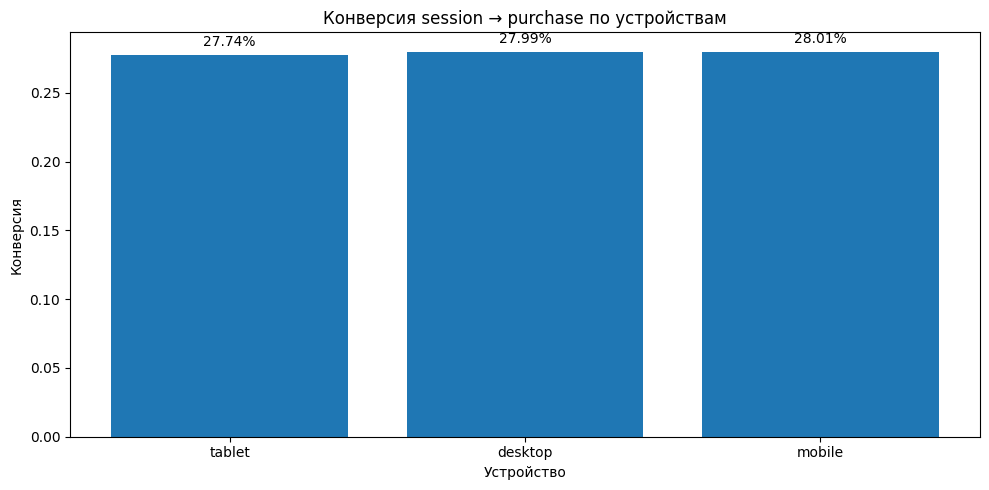

In [19]:
plt.figure(figsize=(10, 5))
ax = plt.gca()
device_plot = device_funnel.sort_values('session_to_purchase_cr')
ax.bar(device_plot['device'], device_plot['session_to_purchase_cr'])
ax.set_title('Конверсия session → purchase по устройствам')
ax.set_xlabel('Устройство')
ax.set_ylabel('Конверсия')
add_labels(ax, device_plot['session_to_purchase_cr'], percent=True)
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / 'device_purchase_cr.png', bbox_inches='tight')
plt.show()


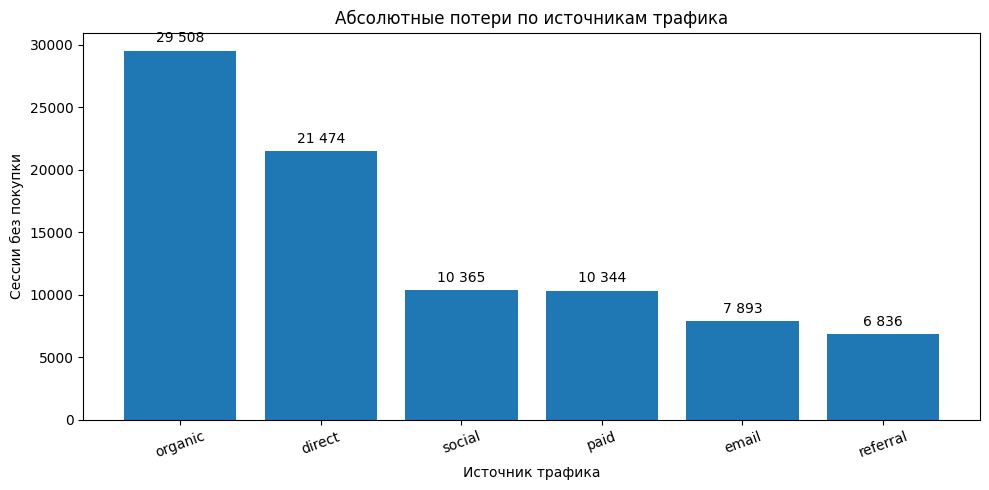

In [20]:
plt.figure(figsize=(10, 5))
ax = plt.gca()
source_plot = source_losses.sort_values('non_purchase_sessions', ascending=False)
ax.bar(source_plot['source'], source_plot['non_purchase_sessions'])
ax.set_title('Абсолютные потери по источникам трафика')
ax.set_xlabel('Источник трафика')
ax.set_ylabel('Сессии без покупки')
plt.xticks(rotation=20)
add_labels(ax, source_plot['non_purchase_sessions'])
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / 'source_non_purchase_sessions.png', bbox_inches='tight')
plt.show()


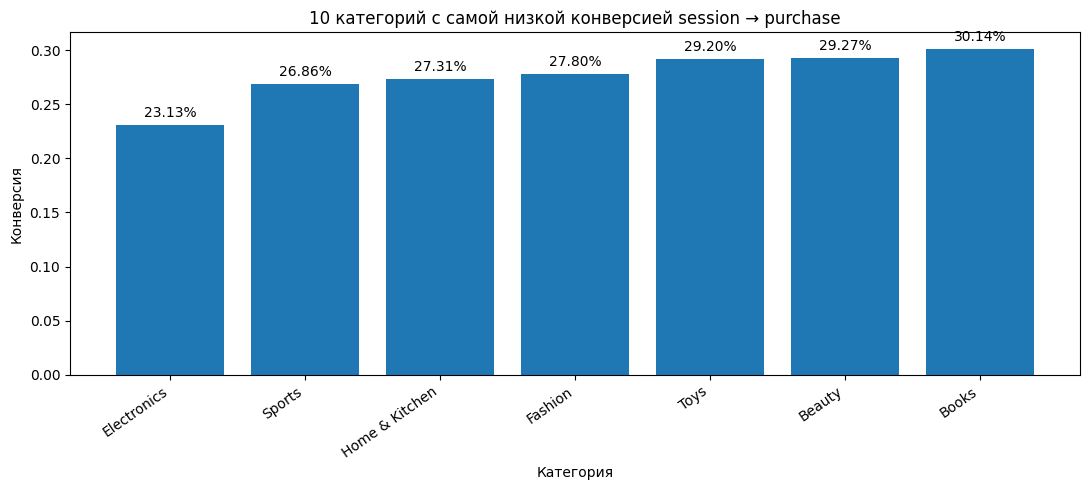

In [21]:
plt.figure(figsize=(11, 5))
ax = plt.gca()
category_plot = category_funnel.sort_values('session_to_purchase_cr').head(10)
ax.bar(category_plot['category'], category_plot['session_to_purchase_cr'])
ax.set_title('10 категорий с самой низкой конверсией session → purchase')
ax.set_xlabel('Категория')
ax.set_ylabel('Конверсия')
plt.xticks(rotation=35, ha='right')
add_labels(ax, category_plot['session_to_purchase_cr'], percent=True)
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / 'low_conversion_categories.png', bbox_inches='tight')
plt.show()


## 9. Сводная таблица приоритизации

Соберем shortlist сегментов, где одновременно:

- плохая конверсия;
- заметный объем потерь;
- высокая ценность для следующего шага анализа.


In [22]:
priority_table = pd.concat([
    device_losses.assign(segment_name='device', segment_value=lambda x: x['device'])[['segment_name', 'segment_value', 'sessions', 'purchases', 'purchase_cr', 'non_purchase_sessions', 'loss_share_total_non_purchases']],
    source_losses.assign(segment_name='source', segment_value=lambda x: x['source'])[['segment_name', 'segment_value', 'sessions', 'purchases', 'purchase_cr', 'non_purchase_sessions', 'loss_share_total_non_purchases']],
    user_type_losses.assign(segment_name='user_type', segment_value=lambda x: x['user_type'])[['segment_name', 'segment_value', 'sessions', 'purchases', 'purchase_cr', 'non_purchase_sessions', 'loss_share_total_non_purchases']],
    category_losses.assign(segment_name='category', segment_value=lambda x: x['category'])[['segment_name', 'segment_value', 'sessions', 'purchases', 'purchase_cr', 'non_purchase_sessions', 'loss_share_total_non_purchases']],
    price_losses.assign(segment_name='price_bucket', segment_value=lambda x: x['price_bucket'].astype(str))[['segment_name', 'segment_value', 'sessions', 'purchases', 'purchase_cr', 'non_purchase_sessions', 'loss_share_total_non_purchases']],
], ignore_index=True)

priority_table['impact_score'] = priority_table['non_purchase_sessions'] * (1 - priority_table['purchase_cr'])
priority_table = priority_table.sort_values(['impact_score', 'non_purchase_sessions'], ascending=False)

priority_table.head(20)


,segment_name,segment_value,sessions,purchases,purchase_cr,non_purchase_sessions,loss_share_total_non_purchases,impact_score
9,user_type,returning,119947,33562,0.2798,86385,0.9996,"62,213.8797"
2,device,mobile,65942,18469,0.2801,47473,0.5493,"34,176.7876"
1,device,desktop,45547,12750,0.2799,32797,0.3795,"23,616.1154"
3,source,organic,40776,11268,0.2763,29508,0.3414,"21,353.7881"
18,price_bucket,100+,36189,9176,0.2536,27013,0.3126,"20,163.6456"
6,source,direct,29861,8387,0.2809,21474,0.2485,"15,442.6401"
19,price_bucket,50-100,29468,8342,0.2831,21126,0.2445,"15,145.5096"
20,price_bucket,25-50,27921,8147,0.2918,19774,0.2288,"14,004.1931"
21,price_bucket,<=25,26422,7915,0.2996,18507,0.2142,"12,963.0251"
17,category,Books,21033,6339,0.3014,14694,0.1700,"10,265.4703"


In [23]:
priority_table.to_csv(OUTPUT_TABLES / 'segment_priority_table.csv', index=False)
print(OUTPUT_TABLES / 'segment_priority_table.csv')


../outputs/tables/segment_priority_table.csv


## 10. Автоматический вывод


In [24]:
worst_device = device_losses.sort_values('purchase_cr').iloc[0]
biggest_source_loss = source_losses.sort_values('non_purchase_sessions', ascending=False).iloc[0]
worst_user_type = user_type_losses.sort_values('purchase_cr').iloc[0]
worst_price = price_losses.sort_values('purchase_cr').iloc[0]

text = f'''
Вывод по сегментному анализу
----------------------------
1. Среди устройств самая низкая конверсия в покупку у сегмента {worst_device['device']} ({worst_device['purchase_cr']:.2%}).

2. Самый большой абсолютный вклад в потери среди источников трафика дает сегмент {biggest_source_loss['source']}: {int(biggest_source_loss['non_purchase_sessions']):,} сессий без покупки.

3. Среди типов пользователей хуже всего конвертируется сегмент {worst_user_type['user_type']} ({worst_user_type['purchase_cr']:.2%}).

4. Среди ценовых сегментов самый слабый результат показывает bucket {worst_price['price_bucket']} ({worst_price['purchase_cr']:.2%}).

Главная мысль: надо различать сегменты с самой слабой конверсией и сегменты с самым большим вкладом в потери.
Для продуктовых решений важны оба типа сигнала.
'''.replace(',', ' ')

print(text)



Вывод по сегментному анализу
----------------------------
1. Среди устройств самая низкая конверсия в покупку у сегмента tablet (27.74%).

2. Самый большой абсолютный вклад в потери среди источников трафика дает сегмент organic: 29 508 сессий без покупки.

3. Среди типов пользователей хуже всего конвертируется сегмент returning (27.98%).

4. Среди ценовых сегментов самый слабый результат показывает bucket 100+ (25.36%).

Главная мысль: надо различать сегменты с самой слабой конверсией и сегменты с самым большим вкладом в потери.
Для продуктовых решений важны оба типа сигнала.



## 11. Рекомендации для кейса

После запуска ноутбука посмотри на top сегменты в `priority_table`.

Именно на их основе потом стоит писать:

- продуктовые гипотезы;
- возможные UX-проблемы;
- приоритеты для A/B-тестов;
- оценку ожидаемого эффекта.
